### Astrostatistic Lecture 4 

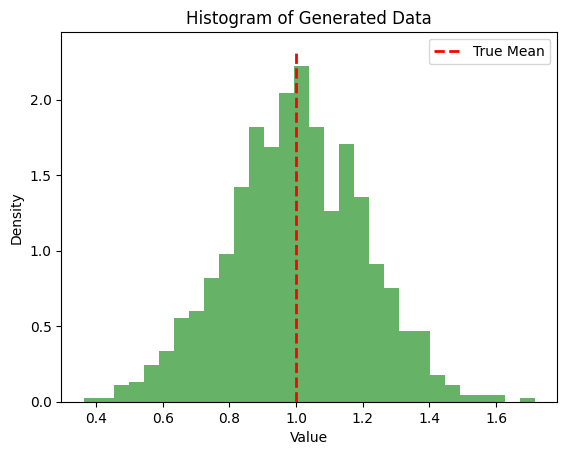

In [17]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import norm

true_mean = 1
true_dev = 0.2
N = 1000
data = np.random.normal(true_mean, true_dev, N) #generating fake data from a gaussian distribution 

plt.hist(data, bins=30, density=True, alpha=0.6, color='g') #plotting the histogram of the data
plt.title('Histogram of Generated Data')
plt.vlines(true_mean, 0, plt.ylim()[1], color='r', linestyle='dashed', linewidth=2, label='True Mean') #plotting the true mean as a vertical line
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


/home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


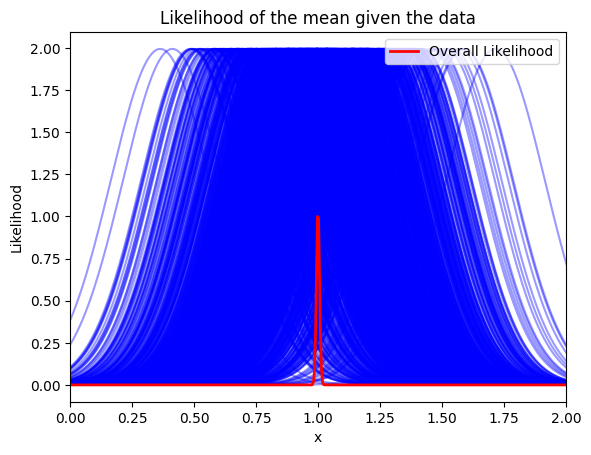

Estimated Mean: 0.997997997997998
Difference between true mean and estimated mean: 0.002002002002001957


In [18]:
overall_array = None  
mu_grid = np.linspace(-1, 3, 1000)

for i, point in enumerate(data):
    likelihood = norm.pdf(point, loc=mu_grid, scale=true_dev) #calculating the likelihood for each point in the data
    plt.plot(mu_grid, likelihood, color='blue', alpha=0.4)
    if i == 0:
        overall_array = likelihood
    else:
        overall_array = overall_array * likelihood   #calculating the overall likelihood by multiplying the likelihoods of all the points in the data

# normalization of the overall likelihood
normalized_array = overall_array / np.max(overall_array)
plt.plot(mu_grid, normalized_array, color='red', linewidth=2, label='Overall Likelihood')
plt.legend()
plt.title('Likelihood of the mean given the data')
plt.xlabel("x")
plt.xlim(0, 2)
plt.ylabel("Likelihood")
plt.show()

estimated_mean = mu_grid[np.argmax(normalized_array)] #the estimated mean is the value of mu that maximizes the overall likelihood
print(f'Estimated Mean: {estimated_mean}')
print(f"Difference between true mean and estimated mean: {abs(true_mean - estimated_mean)}")

In [34]:
#now we basically try to estimate the Fisher information matrix
log_likelihood = np.log(normalized_array) #find the log_likelihood
idx_max = np.argmax(log_likelihood) #find the point where is maximized
second_der = np.diff(log_likelihood, n=2) #calculate the second derivative
normalization = mu_grid[1] - mu_grid[0] #normalization from the grid
fisher_information = - second_der[idx_max-1] / normalization**2 #normalizing the second derivative
sigma = 1/np.sqrt(fisher_information) #the error on the estimated mean is the inverse of the square root of the Fisher information

print(f"Estimated error on the mean: {sigma}")
Real_sigma = true_dev / np.sqrt(N) #real error 
print(f"\nReal error on the mean: {Real_sigma}")
difference = abs(sigma - Real_sigma) #difference between the estimated error and the real error
print(f"\nDifference between estimated error and real error: {difference}")

Estimated error on the mean: 0.006324555320336459

Real error on the mean: 0.006324555320336759

Difference between estimated error and real error: 3.0010716134398763e-16


/tmp/ipykernel_9830/3120011961.py:2: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.log(normalized_array) #find the log_likelihood


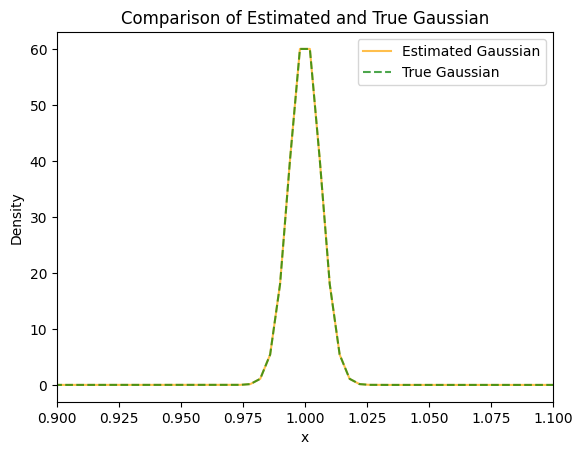

In [32]:
#now we plot a gaussia with true mean and estimated error and see if it matches the real one 
x = np.linspace(-1, 3, 1000)
estimated_gaussian = norm.pdf(x, loc=true_mean, scale=sigma)
true_gaussian = norm.pdf(x, loc=true_mean, scale=Real_sigma)
plt.plot(x, estimated_gaussian, color='orange', label='Estimated Gaussian', alpha=0.7)
plt.plot(x, true_gaussian, color='green', label='True Gaussian', linestyle='dashed', alpha=0.7)
plt.title('Comparison of Estimated and True Gaussian')
plt.xlabel('x')
plt.xlim(0.9, 1.1)
plt.ylabel('Density')
plt.legend()
plt.show()